## EDA y Feature Engineering

In [69]:
# Importar librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Primero, cargamos el archivo original que contiene las etiquetas originales de cada imagen y luego, visualizar las primeras filas para entender la estructura base de este archivo

In [70]:
df = pd.read_csv('./imagenes/ground_truth.csv')
display(df.head(15))

,filename,tom,jerry
0,frame0.jpg,0,0
1,frame1.jpg,0,0
2,frame2.jpg,0,0
3,frame3.jpg,0,0
4,frame4.jpg,0,0
5,frame5.jpg,0,0
6,frame6.jpg,0,0
7,frame7.jpg,0,0
8,frame8.jpg,0,0
9,frame9.jpg,0,0


Como se puede apreciar en el dataframe, este utiliza un formato binario para clasificar las imagenes en base a la presencia (1) o ausencia (0) de cada personaje por separado.

Para poder visualizar la distribucion de las clases y ajustar el dataframe a la estructura de 4 carpetas que leera el modelo a entrenar (`tom`, `jerry`, `tom_jerry_1`, `tom_jerry_0`), se creara una funcion que lea ambas columnas  binarias y asigne a cada fila una categoria unica en texto.

In [71]:
# crear una nueva columna que represente el nombre de las 4 carpetas
def asignar_clase(fila):
    if fila['tom'] == 1 and fila['jerry'] == 0:
        return 'tom'
    elif fila['tom'] == 0 and fila['jerry'] == 1:
        return 'jerry'
    elif fila['tom'] == 1 and fila['jerry'] == 1:
        return 'tom_jerry_1'
    else:
        return 'tom_jerry_0'

In [72]:
# aplicar la funcion al dataframe 
df['categoria'] = df.apply(asignar_clase, axis=1)

In [73]:
# ver como quedo el dataframe luego de agregar la columna nueva
display(df.head(15))

,filename,tom,jerry,categoria
0,frame0.jpg,0,0,tom_jerry_0
1,frame1.jpg,0,0,tom_jerry_0
2,frame2.jpg,0,0,tom_jerry_0
3,frame3.jpg,0,0,tom_jerry_0
4,frame4.jpg,0,0,tom_jerry_0
5,frame5.jpg,0,0,tom_jerry_0
6,frame6.jpg,0,0,tom_jerry_0
7,frame7.jpg,0,0,tom_jerry_0
8,frame8.jpg,0,0,tom_jerry_0
9,frame9.jpg,0,0,tom_jerry_0


Graficar la distribucion de las clases para ver si esta balanceado el dataset

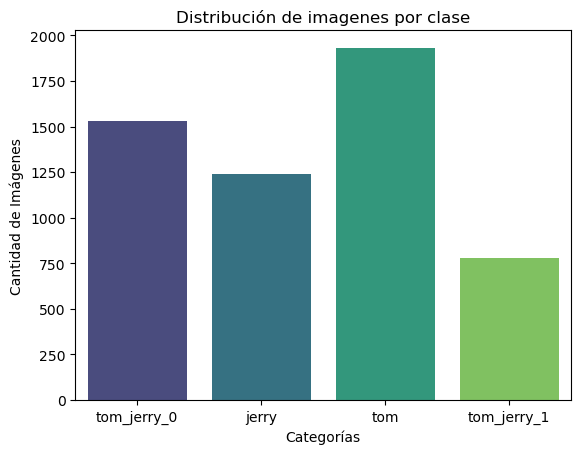

In [87]:
#plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='categoria', hue='categoria', palette='viridis')
plt.title('Distribución de imagenes por clase')
plt.xlabel('Categorías')
plt.ylabel('Cantidad de Imágenes')
plt.savefig("distribucion_clases.png")
plt.show()

A continuacion, se realizara un analisis de las dimensiones de las imagenes ya que, para que ResNet50 pueda procesar las imagenes se requiere que estas tengas un dimensionamiento exacto 

In [75]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
dir_imagenes = './imagenes'
clases = ['tom', 'jerry', 'tom_jerry_1', 'tom_jerry_0']

anchos = []
altos = []

In [77]:
for c in clases:
    ruta_clase = os.path.join(dir_imagenes, c)
    for imagen_nombre in os.listdir(ruta_clase):
        imagen_path = os.path.join(ruta_clase, imagen_nombre)
        with Image.open(imagen_path) as img:
            ancho, alto = img.size
            anchos.append(ancho)
            altos.append(alto)

In [78]:
dimensiones = pd.DataFrame({'Ancho': anchos, 'Alto': altos})

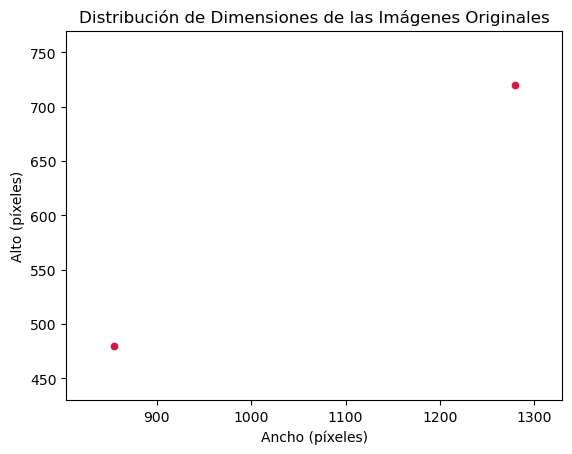

In [88]:
sns.scatterplot(data=dimensiones, x='Ancho', y='Alto', color='crimson')

plt.xlim(dimensiones['Ancho'].min()-50, dimensiones['Ancho'].max()+50)
plt.ylim(dimensiones['Alto'].min()-50, dimensiones['Alto'].max()+50)

plt.title('Distribución de Dimensiones de las Imágenes Originales')
plt.xlabel('Ancho (píxeles)')
plt.ylabel('Alto (píxeles)')
plt.savefig("grafico_dimensiones.png")
plt.show()

### Preparación de las imagenes

In [82]:
import torch
from torchvision import transforms                      #para transformaciones y estandarizacion
from torchvision.datasets import ImageFolder            #para etiquetar cada imagen
from torch.utils.data import DataLoader, random_split   #entrenamiento y division de datos

In [83]:
transformaciones = transforms.Compose([
    transforms.Resize((256, 256)),                  # estandarizar el tamaño de las imagenes a 256 x 256px
    transforms.RandomHorizontalFlip(p=0.5),         # invierte la imagen horizontalmente, para control de overfitting
    transforms.RandomRotation(degrees=15),          # rota la imagen en 15° para evitar overfitting
    transforms.CenterCrop(224),                     # recorta las imagenes en un cuadrado de 224 x 224px
    transforms.ToTensor(),                          # convierta la imagen a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

In [84]:
# cargar el dataset desde la carpeta imagenes y etiqueta cada imagen y aplica las transformacion de arriba
dataset_completo = ImageFolder('./imagenes', transform=transformaciones)

# definir el tamaño de los conjunto de entrenamiento (80%) y conjunto de validacion (20)
entrenamiento_tam = int(0.8 * len(dataset_completo))
validacion_tam = len(dataset_completo) - entrenamiento_tam

# semilla pra que los resultados sean los mismos al ejecutar
generador = torch.Generator().manual_seed(1)

# separa el dataset usando el dataset con las transformaciones, el tamaño de ambos conjuntos y la semilla definida arriba
train_dataset, val_dataset = random_split(dataset_completo, [entrenamiento_tam, validacion_tam], generator=generador)

In [86]:
# crea dataloaders para que el modelo lea en paquetes de 32 imagenes
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# mensajes de confirmacion
print(f"clases detectadas automaticamente: {dataset_completo.classes}")
print(f"total de imagenes para entrenamiento: {len(train_dataset)}")
print(f"total de imágenes para validacion: {len(val_dataset)}")

clases detectadas automaticamente: ['jerry', 'tom', 'tom_jerry_0', 'tom_jerry_1']
total de imagenes para entrenamiento: 4382
total de imágenes para validacion: 1096
